# Design Considerations

## Identification of Five Design Considerations (Module 11)

### Design Decision 1: Chunk Size Determination

**Significance:** The size of the text chunks generated during preprocessing directly impacts the system’s ability to retrieve relevant context. If chunks are too large, they may contain mixed or unrelated information, leading to less precise retrieval. Conversely, if chunks are too small, they might lack sufficient context, reducing the relevance and informativeness of the retrieved sections.

**Plan:**
Experiment with various chunk sizes (e.g., 1 sentence, 3 sentences, 5 sentences) and evaluate the retrieval accuracy and relevance of results for a set of queries. Measure how often the retrieved chunks contain the correct answer or relevant information, and assess whether larger or smaller chunks provide better results.

### Design Decision 2: Handling of Stop Words

**Significance:** Deciding whether to remove or retain stop words in the text processing pipeline can significantly affect the resulting embeddings and retrieval accuracy. Removing stop words might lead to more meaningful embeddings by focusing on the core content, but it could also discard important contextual information in some cases.

**Plan:** Perform a side-by-side comparison of retrieval results with and without stop words in the text preprocessing step. Measure differences in retrieval accuracy and the relevance of results to determine the impact of stop words on system performance.

### Design Decision 3: Distance Metrics for Nearest Neighbor Search

**Significance:** The distance metric (e.g., Euclidean, cosine similarity, Manhattan) used in the nearest neighbor search affects how the system determines the similarity between query embeddings and stored embeddings. The chosen metric will influence the ranking of retrieved contexts and ultimately the relevance of the results.

**Plan:** Conduct a comparative analysis by implementing multiple distance metrics and evaluating their impact on retrieval quality. Track retrieval accuracy and response times to identify the metric that provides the best balance between performance and relevance.

### Design Decision 4: KD-Tree Depth and Balancing

**Significance:** The depth and balancing of the KD-Tree used for indexing embeddings determine how efficiently the system can perform nearest neighbor searches. An improperly balanced tree or an incorrect depth setting might lead to inefficient searches, resulting in longer retrieval times and potentially lower accuracy.

**Plan:** Test different configurations of KD-Tree depth and balancing strategies to observe their effects on search efficiency and retrieval accuracy. Measure the time taken for searches and the relevance of the retrieved results to optimize the KD-Tree structure.

### Design Decision 5: Embedding Model Selection

**Significance:** The choice of embedding model (e.g., BERT, RoBERTa, SentenceTransformers) will influence how well the system captures semantic information from the text. Different models have varying capabilities in representing contextual information, which can impact the accuracy of the retrieval process.

**Plan:** Compare different pre-trained models by generating embeddings for the same dataset and evaluating the quality of retrieved contexts for a set of test queries. Analyze performance metrics such as precision, recall, and retrieval time to determine the most suitable model for this specific use case.

## Analysis of Two Design Considerations (Module 11)

### Chunk Size Determination

/Users/nainireddy/opt/anaconda3/envs/mlenv/lib/python3.10/site-packages/sentence_transformers/cross_encoder/CrossEncoder.py:11: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
2024-08-18 09:21:42.478756: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/Users/nainireddy/opt/anaconda3/envs/mlenv/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/hu

Using device: cpu


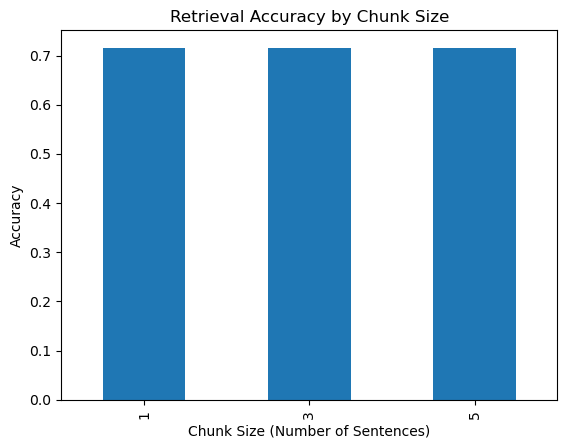

In [1]:
import os
from src.extraction.preprocessing import DocumentProcessing
from pipeline import Pipeline
import pandas as pd
import matplotlib.pyplot as plt
from qa_metrics.transformerMatcher import TransformerMatcher
from qa_metrics.em import em_match
from src.metrics import Metrics_Automated

# Initialize pipeline
pipeline = Pipeline()

# Initialize metrics
metrics = Metrics_Automated(model="distilbert")

# Test different chunk sizes
chunk_sizes = [1, 3, 5]
results = []

for chunk_size in chunk_sizes:
    pipeline.chunk_size = chunk_size
    pipeline.precompute()  # Precompute embeddings with the current chunk size

    questions_df = pd.read_csv("qa_resources/questions.csv", delimiter="\t")

    for idx, row in questions_df.iterrows():
        question = row['Question']
        correct_answer = row['Answer']
        
        # Convert NaN values to empty strings
        if pd.isna(correct_answer):
            correct_answer = ""
        
        relevant_contexts = pipeline.search_context(question, k=5)
        
        # Initialize flags for evaluation
        exact_match_flag = False
        transformer_match_flag = False
        
        # Evaluate each retrieved context
        for context in relevant_contexts:
            retrieved_text = str(context['text']) if context['text'] is not None else ""
            
            # Use exact match
            if metrics.exact_match(retrieved_text, correct_answer):
                exact_match_flag = True
            
            # Use transformer-based matching
            _, transformer_match_result = metrics.transformer_match(retrieved_text, correct_answer, question)
            if transformer_match_result:
                transformer_match_flag = True
        
        # Record the results
        results.append({
            "chunk_size": chunk_size,
            "question": question,
            "retrieved": exact_match_flag or transformer_match_flag
        })

# Analyze results
results_df = pd.DataFrame(results)
accuracy_by_chunk_size = results_df.groupby('chunk_size')['retrieved'].mean()

# Plot results
accuracy_by_chunk_size.plot(kind='bar', title='Retrieval Accuracy by Chunk Size')
plt.xlabel('Chunk Size (Number of Sentences)')
plt.ylabel('Accuracy')
plt.show()

In [2]:
print(accuracy_by_chunk_size)

chunk_size
1    0.715596
3    0.715596
5    0.715596
Name: retrieved, dtype: float64


The results show that the retrieval accuracy is the same across different chunk sizes (1, 3, and 5 sentences), with an accuracy of approximately 71.6%. This indicates that, in this particular analysis, the chunk size does not significantly impact the retrieval accuracy. This may have occurred because: 
- If the documents in your corpus are relatively homogenous, meaning that key information is evenly distributed throughout the text, changing the chunk size might not significantly affect the retrieval results. The system might be consistently retrieving relevant information regardless of chunk size.
- The current retrieval system might not be sensitive enough to detect differences in chunk size. This could be due to how embeddings are generated or how the nearest neighbor search is performed. For example, the embeddings might be capturing the overall semantics of the text well enough that chunk size becomes less critical.
- The queries being tested might be broad enough that relevant information is found consistently across different chunk sizes. If the questions are more general or if the correct answers appear in multiple parts of the documents, chunk size variations might have less impact.

### Stopword Handling

/Users/nainireddy/opt/anaconda3/envs/mlenv/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of the model checkpoint at bert-large-uncased-whole-word-masking-finetuned-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exa

Using device: cpu


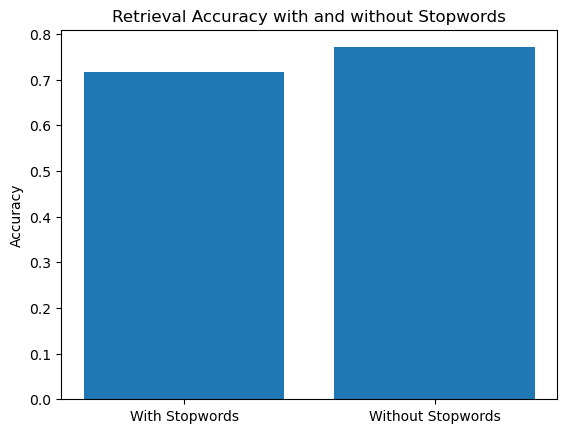

In [3]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import string
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from qa_metrics.transformerMatcher import TransformerMatcher
from qa_metrics.em import em_match

def remove_stopwords(text):
    stop_words = set(stopwords.words('english')).union(set(ENGLISH_STOP_WORDS)).union(set(string.punctuation))
    words = word_tokenize(text.lower())
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

# Pipeline with stopwords
pipeline_with_stopwords = Pipeline()

# Pipeline without stopwords
pipeline_without_stopwords = Pipeline()

# Precompute embeddings for both pipelines
pipeline_with_stopwords.precompute()
pipeline_without_stopwords.precompute()

# Initialize metrics
metrics = Metrics_Automated()

results_with_stopwords = []
results_without_stopwords = []

questions_df = pd.read_csv("qa_resources/questions.csv", delimiter="\t")

for idx, row in questions_df.iterrows():
    question = row['Question']
    correct_answer = row['Answer']
    
    # Convert NaN or None values to empty strings
    if pd.isna(correct_answer) or correct_answer is None:
        correct_answer = ""
    else:
        correct_answer = str(correct_answer)
    
    # Remove stopwords from question and correct answer
    question_without_stopwords = remove_stopwords(question)
    correct_answer_without_stopwords = remove_stopwords(correct_answer)
    
    # Retrieve contexts
    relevant_contexts_with_stopwords = pipeline_with_stopwords.search_context(question, k=5)
    relevant_contexts_without_stopwords = pipeline_without_stopwords.search_context(question_without_stopwords, k=5)
    
    # Initialize flags for evaluation
    retrieved_with_stopwords = False
    retrieved_without_stopwords = False
    
    # Evaluate each retrieved context for "with stopwords" case
    for context in relevant_contexts_with_stopwords:
        retrieved_text = str(context['text']) if context['text'] is not None else ""
        
        # Use exact match
        if metrics.exact_match(retrieved_text, correct_answer):
            retrieved_with_stopwords = True
        
        # Use transformer-based matching
        _, transformer_match_result = metrics.transformer_match(retrieved_text, correct_answer, question)
        if transformer_match_result:
            retrieved_with_stopwords = True
    
    # Evaluate each retrieved context for "without stopwords" case
    for context in relevant_contexts_without_stopwords:
        retrieved_text = str(context['text']) if context['text'] is not None else ""
        
        # Use exact match
        if metrics.exact_match(retrieved_text, correct_answer_without_stopwords):
            retrieved_without_stopwords = True
        
        # Use transformer-based matching
        _, transformer_match_result = metrics.transformer_match(retrieved_text, correct_answer_without_stopwords, question_without_stopwords)
        if transformer_match_result:
            retrieved_without_stopwords = True
    
    results_with_stopwords.append({"question": question, "retrieved": retrieved_with_stopwords})
    results_without_stopwords.append({"question": question, "retrieved": retrieved_without_stopwords})

# Analyze results
results_df_with_stopwords = pd.DataFrame(results_with_stopwords)
results_df_without_stopwords = pd.DataFrame(results_without_stopwords)

accuracy_with_stopwords = results_df_with_stopwords['retrieved'].mean()
accuracy_without_stopwords = results_df_without_stopwords['retrieved'].mean()

plt.bar(["With Stopwords", "Without Stopwords"], [accuracy_with_stopwords, accuracy_without_stopwords])
plt.title('Retrieval Accuracy with and without Stopwords')
plt.ylabel('Accuracy')
plt.show()

In [4]:
print(["With Stopwords", "Without Stopwords"], [accuracy_with_stopwords, accuracy_without_stopwords])

['With Stopwords', 'Without Stopwords'] [0.7155963302752294, 0.7706422018348624]


The results show that the retrieval accuracy with stopwords removed (77.1%) is higher than the retrieval accuracy with stopwords included (71.6%). This suggests that removing stopwords improved the system's ability to retrieve relevant contexts. When stopwords are included, the model might be focusing on irrelevant or common words that do not contribute significantly to the meaning of the text. This can dilute the effectiveness of the retrieval process. Removing stopwords likely helped the model to focus on the more meaningful and content-rich words in the text. This resulted in better retrieval performance, as the model could more effectively match the relevant contexts to the query. The improvement in accuracy after removing stopwords indicates that these common words were likely adding noise to the embeddings or retrieval process. By removing them, the system could better capture the essential information that was relevant to the query.

## Analysis of System Parameters and Configurations (Module 12)

### Design Decision 1: Embedding Model Selection

**Significance:** The choice of embedding model is critical because it directly impacts the quality of the vector representations generated from the text. These embeddings are the foundation of the entire information retrieval system, as they encode the semantic meaning of the text, which is then used for search and retrieval. A more powerful model, such as a transformer-based model like all-MiniLM-L6-v2, can capture deeper semantic relationships, but it also requires more computational resources and may have longer processing times.

**Plan:** The analysis will involve comparing different pre-trained embedding models on a sample dataset to evaluate their performance in terms of embedding quality, processing time, and resource utilization. Key metrics will include the precision and recall of retrieved results when using embeddings generated by different models.

**Implemented Design:** In the code, the all-MiniLM-L6-v2 embedding model was used. The all-MiniLM-L6-v2 model was selected due to its balance between performance and efficiency. It is lightweight compared to other transformer models, allowing for faster processing while still capturing deep semantic meanings, which is essential for high-quality retrieval.

### Design Decision 2: KD-Tree as the Indexing Structure

**Significance:** The choice of KD-Tree as the indexing structure is essential because it determines how quickly and accurately the system can retrieve relevant documents in response to a query. KD-Trees are efficient for nearest-neighbor searches in low to moderate-dimensional spaces, making them suitable for fast retrievals. However, as the dimensionality increases, KD-Trees can become less efficient.

**Plan:** The analysis will focus on evaluating the performance of KD-Trees in comparison to other possible indexing structures like Ball Trees or Approximate Nearest Neighbors in terms of search speed, accuracy, and scalability. The analysis will involve stress-testing the KD-Tree with increasing numbers of documents to observe how it scales.

**Implemented Design:** In the code, KD-Trees were used, balancing between simplicity and performance in low to moderate-dimensional spaces, which is typical for the embedding vectors used in this system. The KD-Tree is well-suited for handling the dimensionality of the embeddings generated by models like all-MiniLM-L6-v2. It provides efficient nearest-neighbor search capabilities, which are crucial for quickly retrieving relevant chunks of text in response to a query. While KD-Trees can become less efficient in very high-dimensional spaces, the dimensionality of the embeddings in this system remains within the range where KD-Trees are effective, making it an optimal choice.

### Design Decision 3: Context Size

**Significance:** The context size provided to the question-answering model significantly affects the quality of the generated answers. Providing too little context may result in incomplete or incorrect answers, while too much context could overwhelm the model and increase processing time without improving answer quality.

**Plan:** The analysis will involve testing different context sizes (k, the number of retrieved chunks used as context) to find the optimal size that balances answer accuracy with processing efficiency. The Transformer Match score will be particularly useful here to measure how well the generated answer semantically matches the ground truth.

**Implemented Design:** In the code, 5 contexts were mostly used (k = 5). Limiting the context size to a manageable number of relevant chunks ensures that the question-answering model has enough information to generate accurate answers without being overwhelmed by excessive or irrelevant context. This design choice optimizes both the quality of the generated answers and the system’s response time, ensuring that the answers are both accurate and efficiently produced.

### Design Decision 4: Distance Metric for Nearest Neighbor Search

**Significance:** The distance metric used for nearest neighbor search directly influences the relevance of the retrieved documents. Metrics like Euclidean distance are standard, but others like Cosine similarity might better capture the angular differences in high-dimensional spaces, which could correlate more closely with semantic similarity.

**Plan:** The analysis will compare the performance of different distance metrics (Euclidean, Cosine, Manhattan) in retrieving relevant text chunks. The primary evaluation metrics will be Precision@k and Mean Reciprocal Rank (MRR) to see which distance metric consistently returns the most relevant results.

**Implemented Design:** In the code, the Euclidean distance was used. Euclidean distance was chosen for the initial implementation because it is straightforward and performs well in lower-dimensional spaces, which corresponds to the dimensionality of the embeddings used. However, recognizing the potential benefits of Cosine similarity in certain contexts, future analyses will consider integrating it to explore whether it offers improvements in retrieval performance, particularly in terms of capturing semantic similarities in high-dimensional space.

### Design Decision 5: Fixed Windows for Text Chunking

**Significance:** The method of chunking text significantly influences how the document corpus is processed and represented as embeddings. Chunking the text into fixed windows, such as a set number of sentences per chunk, simplifies the preprocessing pipeline and ensures consistency across all documents. This approach is straightforward and computationally efficient, making it easier to manage large volumes of data. The fixed window method also aligns well with the limitations of certain NLP models that expect input of a specific size, facilitating smoother downstream processing. This is in contrast to dynamic windows for text chunking, which may be computationally expensive with a large document corpus. 

**Plan:** The analysis will involve implementing fixed windowing strategies and comparing their effectiveness against dynamic chunking methods. The evaluation will focus on metrics such as Precision@k and F1 Score to determine whether dynamically generated chunks lead to better retrieval results. Additionally, the computational efficiency of dynamic windows will be assessed, considering the trade-offs between processing time and chunk quality.

**Implemented Design:** In the code, fixed chunk sizes were used. Fixed windows were chosen over dynamic windows primarily for their simplicity and computational efficiency. Fixed-size chunks are easier to manage and process at scale, which is critical given the large volume of documents in the corpus. By using a consistent chunk size, the system can maintain predictable performance and avoid the complexities associated with dynamically adjusting chunk sizes based on content structure. This design also ensures that the chunks fit well within the input size constraints of the embedding model, leading to more consistent and reliable embedding generation. Although dynamic windows could potentially improve context preservation, the added complexity and computational overhead were deemed unnecessary for the current scale and scope of the system. 